In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from IPython.display import display

In [8]:
# 1. Tải và xem trước dữ liệu
df = pd.read_csv('../data/raw/daily-min-temperatures.csv', parse_dates=['Date'], index_col='Date')
display(df.head())
display(df.info())

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3650 entries, 1981-01-01 to 1990-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Temp    3650 non-null   float64
dtypes: float64(1)
memory usage: 57.0 KB


None

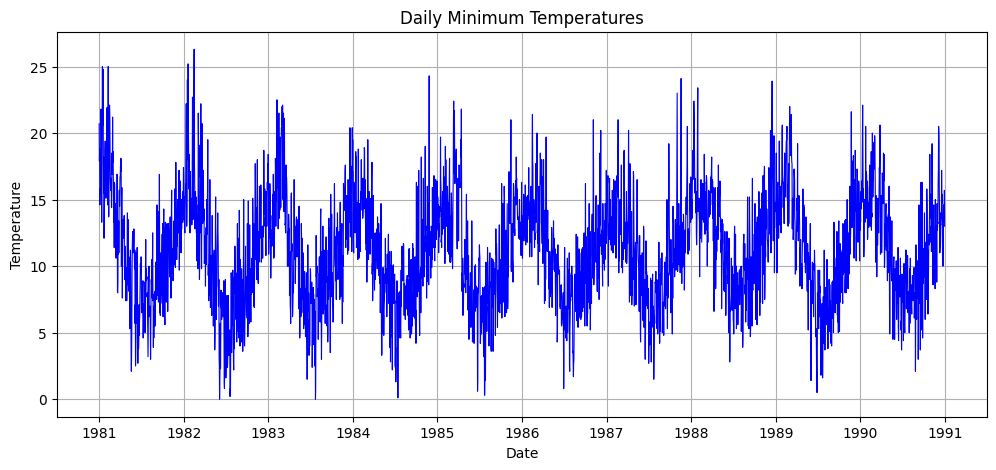

In [9]:
# Vẽ plot tổng quan
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Temp'], color='blue', linewidth=0.8)
plt.title('Daily Minimum Temperatures')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.grid(True)
plt.show()

In [10]:
# 2. Tính ACF, PACF đến 40 lags.
# Tính các giá trị ACF & PACF (40 lags)
acf_values = acf(df['Temp'], nlags=40)
pacf_values = pacf(df['Temp'], nlags=40, method='ywm')
print(" Giá trị ACF (40 lags) ")
print(acf_values)
print("\n Giá trị PACF (40 lags) ")
print(pacf_values)


 Giá trị ACF (40 lags) 
[1.         0.774268   0.6302866  0.58529312 0.57774567 0.57728013
 0.57510412 0.57437039 0.56782622 0.56120131 0.54668689 0.53793111
 0.54012564 0.54247126 0.53688723 0.53429917 0.53043593 0.52911166
 0.53037444 0.52280732 0.52303677 0.52224579 0.51426684 0.49837745
 0.49302665 0.49946731 0.50428521 0.50068173 0.49157081 0.48146406
 0.47421245 0.47568054 0.46311862 0.46215585 0.46630567 0.45459092
 0.43378232 0.4203594  0.42707505 0.42196486 0.4079607 ]

 Giá trị PACF (40 lags) 
[ 1.00000000e+00  7.74268002e-01  7.68912907e-02  1.89057786e-01
  1.51724252e-01  1.29451487e-01  1.09110563e-01  1.02801877e-01
  7.39925795e-02  6.97976999e-02  3.50866667e-02  4.76674634e-02
  6.01486719e-02  5.05787779e-02  3.22628905e-02  4.50175277e-02
  3.13790412e-02  3.90424525e-02  4.07371723e-02  1.38081870e-02
  4.10276037e-02  2.47804204e-02  8.56378650e-03 -1.08501868e-02
  1.47453908e-02  3.06974043e-02  2.43686611e-02  1.04223193e-02
  2.90022333e-03 -3.10081195e-03 -9.

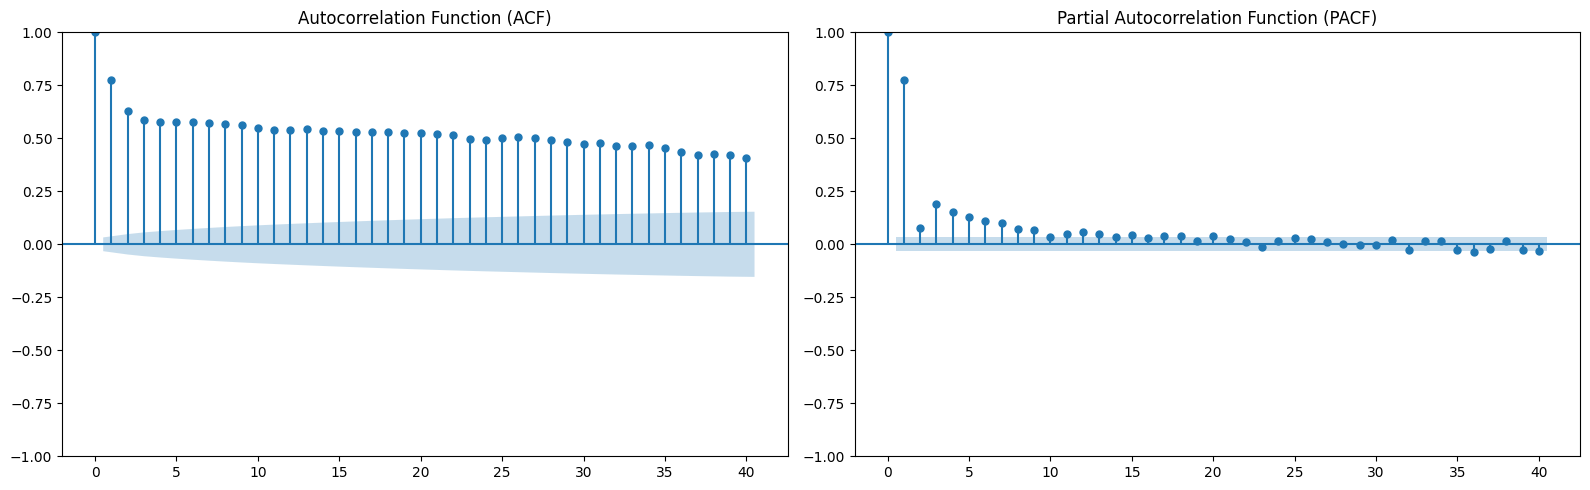

In [11]:
# Biểu đồ tổng quan ACF & PACF
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# ACF
plot_acf(df['Temp'], lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')
# PACF
plot_pacf(df['Temp'], lags=40, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()
